In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("marketing_AB.csv")

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [5]:
df.head()
df.info()
df.describe()
df.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Unnamed: 0       588101
user id          588101
test group            2
converted             2
total ads           807
most ads day          7
most ads hour        24
dtype: int64

In [6]:
df = df.drop("Unnamed: 0", axis=1)


In [7]:
df = df.rename(columns={
    "user id": "user_id",
    "test group": "group",
    "converted": "converted",
    "total ads": "total_ads",
    "most ads day": "most_ads_day",
    "most ads hour": "most_ads_hour"
})


In [8]:
df.isnull().sum()


user_id          0
group            0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [9]:
df['group'].value_counts()


group
ad     564577
psa     23524
Name: count, dtype: int64

In [10]:
conversion_rates = df.groupby("group")['converted'].mean()
conversion_rates


group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [11]:
from statsmodels.stats.proportion import proportions_ztest

success = df.groupby('group')['converted'].sum()
total = df.groupby('group')['converted'].count()

success_counts = [success['ad'], success['psa']]
total_counts = [total['ad'], total['psa']]

z_stat, p_value = proportions_ztest(success_counts, total_counts)
z_stat, p_value


(7.3700781265454145, 1.7052807161559727e-13)

In [12]:
import numpy as np
from math import sqrt
p1= success['ad']/total['ad']
p2= success['psa']/total['psa']
se=sqrt(p1*(1-p1)/total['ad']+p2*(1-p2)/total['psa'])
lower= (p1-p2)-1.96*se
upper=(p1-p2)+1.96*se
(p1 - p2), lower, upper

(0.007692453192201517, 0.00595090043017032, 0.009434005954232714)

In [13]:
p1=df[df['group']=='ad']['converted'].mean()
p2=df[df['group']=='psa']['converted'].mean()

In [14]:
cohens_h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))
cohens_h

0.053002578606030915

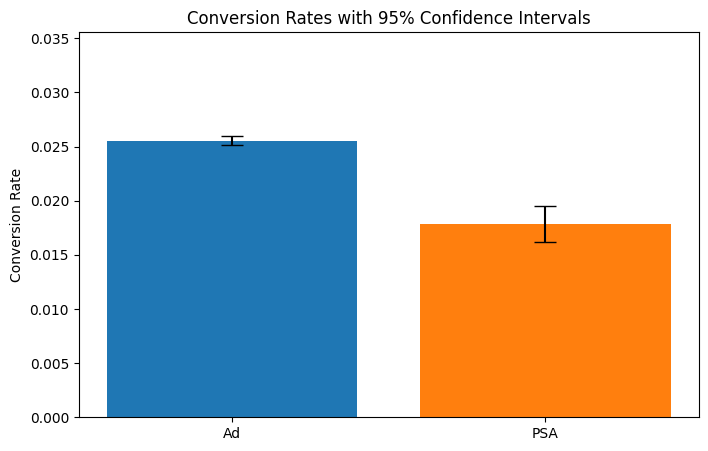

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Conversion rates
cr_ad = df[df['group']=='ad']['converted'].mean()
cr_psa = df[df['group']=='psa']['converted'].mean()

# Standard errors
n_ad = df[df['group']=='ad'].shape[0]
n_psa = df[df['group']=='psa'].shape[0]

se_ad = np.sqrt(cr_ad*(1-cr_ad)/n_ad)
se_psa = np.sqrt(cr_psa*(1-cr_psa)/n_psa)

# 95% CI
ci_ad = (cr_ad - 1.96*se_ad, cr_ad + 1.96*se_ad)
ci_psa = (cr_psa - 1.96*se_psa, cr_psa + 1.96*se_psa)

# Plotting
groups = ['Ad', 'PSA']
rates = [cr_ad, cr_psa]
lower_err = [rates[i] - [ci_ad, ci_psa][i][0] for i in range(2)]
upper_err = [[ci_ad, ci_psa][i][1] - rates[i] for i in range(2)]
error = [lower_err, upper_err]

plt.figure(figsize=(8,5))
plt.bar(groups, rates, yerr=error, capsize=8, color=['#1f77b4', '#ff7f0e'])
plt.ylabel("Conversion Rate")
plt.title("Conversion Rates with 95% Confidence Intervals")
plt.ylim(0, max(rates) + 0.01)
plt.show()


In [16]:
cr_ad = df[df['group']=='ad']['converted'].mean()
cr_psa = df[df['group']=='psa']['converted'].mean()

lift = (cr_ad - cr_psa) / cr_psa

cr_ad, cr_psa, lift


(0.025546559636683747, 0.01785410644448223, 0.43085064022225833)